In [16]:
import numpy as np
import cv2
from typing import List, Tuple, Any, Dict
import os
import glob
import pickle
from matplotlib import pyplot as plt

In [17]:
squareLength = 0.0200 # m
markerLength = 0.0150 # m
squaresX = 11
squaresY = 8

In [18]:
def load_image_pairs(set: str) -> List[Tuple[str, str]]:
    n_files = int(len(glob.glob(os.path.join(set, r"*.png"))) / 2)
    return [(os.path.join(set, f"left-{i}.png"), os.path.join(set, f"right-{i}.png")) for i in range(n_files)]
pairs = [
    *load_image_pairs("set_1")
    , *load_image_pairs("set_2")
    # , *load_image_pairs("set_3")
    # , *load_image_pairs("set_4")
]
print(f"{len(pairs)} calibration images found")

34 calibration images found


In [19]:
dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
board = cv2.aruco.CharucoBoard((squaresX, squaresY), squareLength, markerLength, dict)
detectors = (
    cv2.aruco.CharucoDetector(board),
    cv2.aruco.CharucoDetector(board)
)

In [20]:
MIN_POINTS = 6

In [21]:
def _prune_ids(idl, objl, imgl, idr, objr, imgr):
    idl2 = []
    objl2 = []
    imgl2 = []
    idr2 = []
    objr2 = []
    imgr2 = []

    for i in range(len(idl)):
        if idl[i] in idr:
            idl2.append(idl[i])
            objl2.append(objl[i])
            imgl2.append(imgl[i])    
    for i in range(len(idr)):
        if idr[i] in idl:
            idr2.append(idr[i])
            objr2.append(objr[i])
            imgr2.append(imgr[i])

    return np.array(idl2), np.array(objl2), np.array(imgl2), np.array(idr2), np.array(objr2), np.array(imgr2)

def _check_homography(imgpoints, objpoints):
    H, m = cv2.findHomography(objpoints, imgpoints)
    return (H is not None) and (H.shape == (3,3))

def get_calib_points(files: List[Tuple[str, str]]):
    objpointsl = []
    objpointsr = []
    objpointsb = []
    imgpointsr = []
    imgpointsl = []
    imgpointsbl = []
    imgpointsbr = []

    for fl, fr in files:
        iml = cv2.imread(fl, cv2.IMREAD_GRAYSCALE)
        imr = cv2.imread(fr, cv2.IMREAD_GRAYSCALE)

        charuco_corners_l, charucos_ids_l, marker_corners_l, marker_ids_l = \
            detectors[0].detectBoard(iml)
        charuco_corners_r, charucos_ids_r, marker_corners_r, marker_ids_r = \
            detectors[1].detectBoard(imr)
        
        if (charucos_ids_l is not None) and (charucos_ids_r is not None) \
            and (len(charucos_ids_l) >= MIN_POINTS) and (len(charucos_ids_r) >= MIN_POINTS):

            charuco_corners_l_refined = cv2.cornerSubPix(iml, charuco_corners_l, (11,11), (-1,-1), (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
            charuco_corners_r_refined = cv2.cornerSubPix(imr, charuco_corners_r, (11,11), (-1,-1), (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
                            
            objpoints_l, imgpoints_l = board.matchImagePoints(charuco_corners_l_refined, charucos_ids_l)
            objpoints_r, imgpoints_r = board.matchImagePoints(charuco_corners_r_refined, charucos_ids_r)

            cv2.aruco.drawDetectedCornersCharuco(iml, charuco_corners_l_refined)
            cv2.imwrite(os.path.join("debug", fl), cv2.aruco.drawDetectedMarkers(iml, marker_corners_l, marker_ids_l))
            cv2.aruco.drawDetectedCornersCharuco(imr, charuco_corners_r_refined)
            cv2.imwrite(os.path.join("debug", fr), cv2.aruco.drawDetectedMarkers(imr, marker_corners_r, marker_ids_r))
            
            if _check_homography(imgpoints_l, objpoints_l):
                objpointsl.append(objpoints_l)
                imgpointsl.append(imgpoints_l)
            else:
                print(f"Transform could not be computed for {fl}")            
            
            if _check_homography(imgpoints_r, objpoints_r):
                objpointsr.append(objpoints_r)
                imgpointsr.append(imgpoints_r)
            else:
                print(f"Transform could not be computed for {fr}")

            charucos_ids_l2, objpoints_l2, imgpoints_l2, charucos_ids_r2, objpoints_r2, imgpoints_r2 = \
                _prune_ids(charucos_ids_l, objpoints_l, imgpoints_l, charucos_ids_r, objpoints_r, imgpoints_r)  
            
            if (len(charucos_ids_l2) >= MIN_POINTS) and (len(charucos_ids_r2) >= MIN_POINTS) \
                and _check_homography(imgpoints_l, objpoints_l) and _check_homography(imgpoints_r, objpoints_r):
                
                objpointsb.append(objpoints_l2)
                imgpointsbl.append(imgpoints_l2)
                imgpointsbr.append(imgpoints_r2)

    return (
        (imgpointsl, objpointsl),
        (imgpointsr, objpointsr),
        (imgpointsbl, imgpointsbr, objpointsb)
    )


In [22]:
def calib_heatmaps(files):
    hml = None
    hmr = None
    for fl, fr in files:
        iml = cv2.imread(fl, cv2.IMREAD_GRAYSCALE)
        imr = cv2.imread(fr, cv2.IMREAD_GRAYSCALE)
        if hml is None:
            hml = np.zeros(iml.shape)
            hmr = np.zeros(imr.shape)

        charuco_corners_l, charucos_ids_l, marker_corners_l, marker_ids_l = \
            detectors[0].detectBoard(iml)
        charuco_corners_r, charucos_ids_r, marker_corners_r, marker_ids_r = \
            detectors[1].detectBoard(imr)
        
        
        if (charucos_ids_l is not None) and (charucos_ids_r is not None) \
            and (len(charucos_ids_l) >= MIN_POINTS) and (len(charucos_ids_r) >= MIN_POINTS):

            objpoints_l, imgpoints_l = board.matchImagePoints(charuco_corners_l, charucos_ids_l)
            objpoints_r, imgpoints_r = board.matchImagePoints(charuco_corners_r, charucos_ids_r)

            cv2.aruco.drawDetectedCornersCharuco(hml, imgpoints_l)
            cv2.aruco.drawDetectedCornersCharuco(hmr, imgpoints_r)   
    
    return hml, hmr


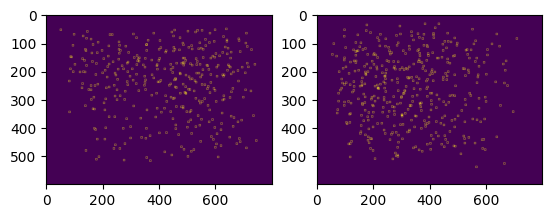

In [23]:
hml, hmr = calib_heatmaps(pairs)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(hml)
ax[1].imshow(hmr)

In [24]:
(imgpointsl, objpointsl), \
(imgpointsr, objpointsr), \
_ = get_calib_points(pairs)

In [25]:
_, _, \
(imgpointsbl, imgpointsbr, objpointsb) = get_calib_points(load_image_pairs("set_3"))

In [26]:
print(f"{len(objpointsl)} left camera calibration sets")
print(f"{len(objpointsr)} right camera calibration sets")
print(f"{len(objpointsb)} stereo camera calibration sets")

15 left camera calibration sets
15 right camera calibration sets
5 stereo camera calibration sets


In [27]:
ret, mtxl, distl, rvecs, tvecs = \
    cv2.calibrateCamera(objpointsl, imgpointsl, (800, 600), None, None, flags=cv2.CALIB_FIX_TANGENT_DIST + cv2.CALIB_FIX_K3 + cv2.CALIB_FIX_K2)
print(f"Left camera reprojection error: {ret}")
ret, mtxr, distr, rvecs, tvecs = \
    cv2.calibrateCamera(objpointsr, imgpointsr, (800, 600), None, None, flags=cv2.CALIB_FIX_TANGENT_DIST + cv2.CALIB_FIX_K3 + cv2.CALIB_FIX_K2)
print(f"Right camera reprojection error: {ret}")

Left camera reprojection error: 0.7020085747984581
Right camera reprojection error: 0.6471819795228322


In [28]:
ret, M1, d1, M2, d2, R, T, E, F = cv2.stereoCalibrate(objpointsb, imgpointsbl, imgpointsbr, mtxl, 
                        distl, mtxr, distr, (800, 600)
                        , flags = cv2.CALIB_FIX_INTRINSIC
                    )
print(f"Stereo reprojection error: {ret}")


Stereo reprojection error: 0.5347623955652323


In [29]:
R1, R2, Pn1, Pn2, Q, ROI1, ROI2 = cv2.stereoRectify(M1, d1, M2, d2, (800,600), R, T)

In [30]:
print(f"Original left Intrinsic: {mtxl}")
print(f"Original left Distortion: {distl}")
print(f"Original right Intrinsic: {mtxr}")
print(f"Original right Distortion: {distr}")

Original left Intrinsic: [[626.9237939    0.         406.00895256]
 [  0.         626.09026459 321.61328135]
 [  0.           0.           1.        ]]
Original left Distortion: [[0.0458753 0.        0.        0.        0.       ]]
Original right Intrinsic: [[637.53533071   0.         410.07476447]
 [  0.         636.74837221 314.74459781]
 [  0.           0.           1.        ]]
Original right Distortion: [[0.04846371 0.         0.         0.         0.        ]]


In [31]:
print(f"Left Intrinsic: {M1}")
print(f"Left Distortion: {d1}")
print(f"Right Intrinsic: {M2}")
print(f"Right Distortion: {d2}")
print(f"Stereo Translation: {T}")
print(f"Stereo Rotation: {R}")
print(f"Stereo Projection: {Q}")

with open("parameters.pickle", "wb") as file:
    pickle.dump((M1, d1, M2, d2, T, R, Q, ROI1, ROI2, R1, R2, Pn1, Pn2), file)

Left Intrinsic: [[626.9237939    0.         406.00895256]
 [  0.         626.09026459 321.61328135]
 [  0.           0.           1.        ]]
Left Distortion: [[0.0458753 0.        0.        0.        0.       ]]
Right Intrinsic: [[637.53533071   0.         410.07476447]
 [  0.         636.74837221 314.74459781]
 [  0.           0.           1.        ]]
Right Distortion: [[0.04846371 0.         0.         0.         0.        ]]
Stereo Translation: [[-0.05621347]
 [ 0.00013104]
 [-0.00182219]]
Stereo Rotation: [[ 0.99962978 -0.0132916  -0.02374101]
 [ 0.01401805  0.99943036  0.03069948]
 [ 0.02331944 -0.03102092  0.99924667]]
Stereo Projection: [[   1.            0.            0.         -389.51855087]
 [   0.            1.            0.         -317.34623337]
 [   0.            0.            0.          631.4193184 ]
 [   0.            0.           17.77994472   -0.        ]]
